In [1]:
import numpy as np
import pandas as pd

from solver import Solver
from src.L0Cor.utils import Build_Design

In [2]:
def generate_data(seed=100, n=100, p1=50, p2=50, k=10, snr=10.0, rho=0.8):
    rng = np.random.default_rng(seed)

    # rho controls the AR(1) correlation inside X1 blocks
    X, Active_Ind = Build_Design(n=n, p1=p1, k=k, p2=p2, seed=seed, rho=rho)

    p = p1 + p2
    beta = np.zeros((p, 1))
    beta[np.array(Active_Ind, dtype=int), 0] = rng.uniform(0, 1, size=k)

    y_s = X @ beta
    Ps = np.mean(np.square(y_s))
    eps = np.sqrt(Ps / snr)
    noise = eps * rng.normal(size=(n, 1))

    y = (y_s + noise).reshape(-1)

    return X, y, np.array(Active_Ind, dtype=int)

def tp_fp_fn(selected, truth):
    selected = set(map(int, selected))
    truth = set(map(int, truth))
    tp = len(selected & truth)
    fp = len(selected - truth)
    fn = len(truth - selected)
    return tp, fp, fn

In [9]:
methods = [
    "our_method",
    "WLasso",
    "MCP",
    "SCAD",
    "HOLP",
    "PrecisionLasso",
    "NCV_Lasso",
    "NCV_ElasticNet",
]

p1 = 80
p2 = 20
k = 10
snr = 10.0

n_grid = list(range(40, 141, 20))
rho_grid = [0.2, 0.4, 0.8]

n_reuse = 40  # runs after tuning run

In [10]:
import os
import numpy as np
import pandas as pd

# ----------------- output files -----------------
OUT_RAW = "benchmark_results_raw_checkpoint_withp2.csv"
OUT_SUM = "benchmark_results_summary_checkpoint_withp2.csv"

# Set True to resume from OUT_RAW if it exists
RESUME = True

# ----------------- seeds -----------------
BASE_TUNE_SEED = 10_000
BASE_RUN_SEED  = 20_000

def _raw_selected_size(sel):
    """Robustly get size even if sel is a scalar numpy.int64."""
    if sel is None:
        return 0
    return int(np.atleast_1d(sel).size)

def tp_fp_fn(selected, truth):
    selected = set(map(int, selected))
    truth = set(map(int, truth))
    tp = len(selected & truth)
    fp = len(selected - truth)
    fn = len(truth - selected)
    return tp, fp, fn

def save_checkpoint(rows):
    df = pd.DataFrame(rows)
    df.to_csv(OUT_RAW, index=False)

    reuse_df = df[df["run"] > 0]
    summary = (
        reuse_df
        .groupby(["rho", "n", "method"])
        .agg(
            TP_mean=("TP", "mean"),
            FP_mean=("FP", "mean"),
            FN_mean=("FN", "mean"),
            runtime_mean=("runtime_sec", "mean"),
            runtime_median=("runtime_sec", "median"),
            raw_selected_mean=("raw_selected_size", "mean"),
        )
        .reset_index()
    )
    summary.to_csv(OUT_SUM, index=False)
    return df, summary

In [12]:
# ----------------- load checkpoint if resuming -----------------
rows = []
done_pairs = set()

if RESUME and os.path.exists(OUT_RAW):
    df_prev = pd.read_csv(OUT_RAW)
    rows = df_prev.to_dict(orient="records")
    done_pairs = set(zip(df_prev["rho"].astype(float), df_prev["n"].astype(int)))
    print(f"Resuming from checkpoint: {OUT_RAW}")
    print(f"Already completed (rho,n) pairs: {len(done_pairs)}")
else:
    print("Starting fresh (no checkpoint found or RESUME=False).")

# ----------------- main loop -----------------
for rho in rho_grid:
    for n in n_grid:
        key = (float(rho), int(n))
        if key in done_pairs:
            print(f"Skipping rho={rho}, n={n} (already in checkpoint).")
            continue

        print(f"\nStarting rho={rho}, n={n} ...")

        # New Solver per (n, rho): tuning is local to that condition
        #S = Solver(models=methods, k_top=k)

        # ---------- Run 0: tune once ----------
        #seed0 = BASE_TUNE_SEED + 1000*n + int(rho*100)
        #X0, y0, A0 = generate_data(seed=seed0, n=n, p1=p1, p2=p2, k=k, snr=snr, rho=rho)

        #out0 = S.fit(X0, y0, run_id=0, seed=1)

        #for m in methods:
        #    topk = out0[m]["selected_topk"]
        #    tp, fp, fn = tp_fp_fn(topk, A0)
        #    sel0 = out0[m].get("selected", None)

        #    rows.append({
        #        "rho": float(rho), "n": int(n), "run": 0, "method": m,
        #        "TP": tp, "FP": fp, "FN": fn,
        #        "runtime_sec": out0[m]["meta"].get("runtime_sec", np.nan),
        #        "raw_selected_size": _raw_selected_size(sel0),
        #        "tuned_params": str(S.best_params.get(m, None)) if m in S.best_params else None,
        #    })

        # ---------- Runs 1..n_reuse: reuse tuned params ----------
        for r in range(1, n_reuse + 1):
            seedr = BASE_RUN_SEED + 1000*n + 10*r + int(rho*100)
            Xr, yr, Ar = generate_data(seed=seedr, n=n, p1=p1, p2=p2, k=k, snr=snr, rho=rho)
            
            # Solver
            S = Solver(models=methods, k_top=k)

            out = S.fit(Xr, yr, run_id=0, seed=1+r)

            for m in methods:
                topk = out[m]["selected_topk"]
                tp, fp, fn = tp_fp_fn(topk, Ar)
                sel = out[m].get("selected", None)

                rows.append({
                    "rho": float(rho), "n": int(n), "run": int(r), "method": m,
                    "TP": tp, "FP": fp, "FN": fn,
                    "runtime_sec": out[m]["meta"].get("runtime_sec", np.nan),
                    "raw_selected_size": _raw_selected_size(sel),
                    "tuned_params": str(S.best_params.get(m, None)) if m in S.best_params else None,
                })

        # mark as done and checkpoint
        done_pairs.add(key)
        df_now, summary_now = save_checkpoint(rows)
        print(f"Finished rho={rho}, n={n} ✅  (checkpoint saved)")
        print(f"Checkpoint rows: {len(df_now)} | summary rows: {len(summary_now)}")

# final DataFrames in memory
df = pd.DataFrame(rows)
reuse_df = df[df["run"] > 0]
summary = (
    reuse_df
    .groupby(["rho", "n", "method"])
    .agg(
        TP_mean=("TP", "mean"),
        FP_mean=("FP", "mean"),
        FN_mean=("FN", "mean"),
        runtime_mean=("runtime_sec", "mean"),
        runtime_median=("runtime_sec", "median"),
        raw_selected_mean=("raw_selected_size", "mean"),
    )
    .reset_index()
)

# print("\nAll done.")
# print(f"Raw saved to: {OUT_RAW}")
# print(f"Summary saved to: {OUT_SUM}")

# df.head()

Resuming from checkpoint: benchmark_results_raw_checkpoint_withp2.csv
Already completed (rho,n) pairs: 11
Skipping rho=0.2, n=40 (already in checkpoint).
Skipping rho=0.2, n=60 (already in checkpoint).
Skipping rho=0.2, n=80 (already in checkpoint).
Skipping rho=0.2, n=100 (already in checkpoint).
Skipping rho=0.2, n=120 (already in checkpoint).
Skipping rho=0.2, n=140 (already in checkpoint).
Skipping rho=0.4, n=40 (already in checkpoint).
Skipping rho=0.4, n=60 (already in checkpoint).
Skipping rho=0.4, n=80 (already in checkpoint).
Skipping rho=0.4, n=100 (already in checkpoint).
Skipping rho=0.4, n=120 (already in checkpoint).

Starting rho=0.4, n=140 ...


/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] + d2 - d1) / (points[notMinPos, 2] - points[minPos, 2] + 2 * d2))
/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] + d2 - d1) / (points[notMinPos, 2] - points[minPos, 2] + 2 * d2))
/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] +

Finished rho=0.4, n=140 ✅  (checkpoint saved)
Checkpoint rows: 3840 | summary rows: 96

Starting rho=0.8, n=40 ...


/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] + d2 - d1) / (points[notMinPos, 2] - points[minPos, 2] + 2 * d2))
/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] + d2 - d1) / (points[notMinPos, 2] - points[minPos, 2] + 2 * d2))
/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] +

Finished rho=0.8, n=40 ✅  (checkpoint saved)
Checkpoint rows: 4160 | summary rows: 104

Starting rho=0.8, n=60 ...


...

Finished rho=0.8, n=100 ✅  (checkpoint saved)
Checkpoint rows: 5120 | summary rows: 128

Starting rho=0.8, n=120 ...


/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] + d2 - d1) / (points[notMinPos, 2] - points[minPos, 2] + 2 * d2))
/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] + d2 - d1) / (points[notMinPos, 2] - points[minPos, 2] + 2 * d2))
/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] +

Finished rho=0.8, n=120 ✅  (checkpoint saved)
Checkpoint rows: 5440 | summary rows: 136

Starting rho=0.8, n=140 ...


/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] + d2 - d1) / (points[notMinPos, 2] - points[minPos, 2] + 2 * d2))
/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] + d2 - d1) / (points[notMinPos, 2] - points[minPos, 2] + 2 * d2))
/Users/yijwang-admin/Documents/Research/Overcome_Correlation/Lasso_Benchmarking-main/src/L0Cor/PQN_Python/minFunc/polyinterp.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  t = points[notMinPos, 0] - (points[notMinPos, 0] - points[minPos, 0]) * ((points[notMinPos, 2] +

Finished rho=0.8, n=140 ✅  (checkpoint saved)
Checkpoint rows: 5760 | summary rows: 144


In [13]:
df.head()

,rho,n,run,method,TP,FP,FN,runtime_sec,raw_selected_size,tuned_params
0,0.2,40,1,our_method,7,3,3,0.040816,10,"{'k_select': 10, 'mu': 3.79269019073225, 'pho'..."
1,0.2,40,1,WLasso,5,5,5,0.889233,9,"{'gamma': 0.95, 'maxsteps': 1000}"
2,0.2,40,1,MCP,1,9,9,0.210535,46,"{'lambda_fixed': 0.2764, 'alpha_fixed': 0.1, '..."
3,0.2,40,1,SCAD,2,8,8,0.145507,16,"{'lambda_fixed': 0.1128, 'alpha_fixed': 0.9, '..."
4,0.2,40,1,HOLP,1,9,9,0.480937,20,{'num_select': 20}


In [ ]:
df.to_csv("run_1_res.csv", index=False)

In [ ]:
summary

In [ ]:
summary.to_csv("run_1_summary.csv", index=False)

In [ ]:
reuse_df

In [ ]:
import matplotlib.pyplot as plt

methods_order = sorted(summary["method"].unique())  # or your preferred order
rho_vals = sorted(summary["rho"].unique())
n_vals = sorted(summary["n"].unique())

for rho in rho_vals:
    plt.figure(figsize=(10,6))
    sub = summary[summary["rho"] == rho]

    for m in methods_order:
        sm = sub[sub["method"] == m].sort_values("n")
        if sm.empty:
            continue
        plt.plot(sm["n"].values, sm["TP_mean"].values, label=m)

    plt.xlabel("n")
    plt.ylabel("Mean TP (top-k)")
    plt.title(f"TP vs n (rho={rho})")
    plt.ylim(0, int(df["TP"].max()) if len(df) else 10)
    plt.legend(loc="best", fontsize=8)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

rho_fixed = 0.2
n_fixed = 100
methods_show = ["our_method", "WLasso", "MCP", "SCAD", "PrecisionLasso"]

sub = reuse_df[(reuse_df["rho"] == rho_fixed) & (reuse_df["n"] == n_fixed) & (reuse_df["method"].isin(methods_show))]
data = [sub[sub["method"] == m]["TP"].values for m in methods_show]

plt.figure(figsize=(10,5))
plt.boxplot(data, labels=methods_show, showfliers=False)
plt.ylabel("TP (per run)")
plt.title(f"TP stability across runs (rho={rho_fixed}, n={n_fixed})")
plt.xticks(rotation=30, ha="right")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

for rho in rho_vals:
    plt.figure(figsize=(10,6))
    sub = summary[summary["rho"] == rho]

    for m in methods_order:
        sm = sub[sub["method"] == m].sort_values("n")
        if sm.empty:
            continue
        plt.plot(sm["n"].values, sm["runtime_mean"].values, label=m)

    plt.xlabel("n")
    plt.ylabel("Mean runtime (sec)")
    plt.title(f"Runtime vs n (rho={rho})")
    plt.legend(loc="best", fontsize=8)
    plt.show()

In [ ]:
np.logspace(-1, 1.0, 20)

# Read in results 

In [14]:
df = pd.read_csv("benchmark_results_raw_checkpoint_withp2.csv")

In [15]:
df_best = (
    df.sort_values("TP", ascending=False)
      .groupby(["rho", "n", "method"])
      .head(10)
)

In [16]:
df_sorted = df_best.sort_values(by=['rho', "n", "method"], ascending=[True, True, True]).reset_index(drop=True)

In [17]:
df_sorted

,rho,n,run,method,TP,FP,FN,runtime_sec,raw_selected_size,tuned_params
0,0.2,40,5,HOLP,2,8,8,0.478614,20,{'num_select': 20}
1,0.2,40,30,HOLP,2,8,8,0.475395,100,{'num_select': 100}
2,0.2,40,28,HOLP,2,8,8,0.477522,20,{'num_select': 20}
3,0.2,40,1,HOLP,1,9,9,0.480937,20,{'num_select': 20}
4,0.2,40,14,HOLP,1,9,9,0.477404,20,{'num_select': 20}
...,...,...,...,...,...,...,...,...,...,...
1435,0.8,140,36,our_method,9,1,1,1.537593,10,"{'k_select': 10, 'mu': 31.622776601683793, 'ph..."
1436,0.8,140,28,our_method,8,2,2,2.204509,10,"{'k_select': 10, 'mu': 12.742749857031335, 'ph..."
1437,0.8,140,22,our_method,8,2,2,3.319981,10,"{'k_select': 10, 'mu': 0.45487779470037765, 'p..."
1438,0.8,140,32,our_method,8,2,2,2.572345,10,"{'k_select': 10, 'mu': 2.8013567611988672, 'ph..."


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# group by (rho, n, method) if you want per method
df_stats = (
    df_best.groupby(["rho", "n", "method"])["TP"]
    .agg(mean_TP="mean", var_TP="var")
    .reset_index()
)

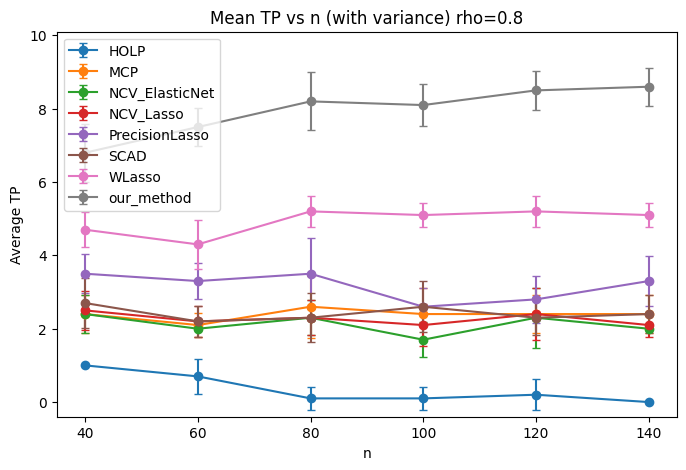

In [34]:
df_stats_sub = df_stats[df_stats["rho"] == 0.8]
methods = df_stats_sub["method"].unique()
#methods = df_stats["method"].unique()

plt.figure(figsize=(8,5))

for method in methods:
    df_plot = df_stats_sub[df_stats_sub["method"] == method]
    plt.errorbar(
        df_plot["n"],
        df_plot["mean_TP"],
        yerr=df_plot["var_TP"]**0.5,
        marker='o',
        capsize=3,
        label=method
    )

plt.xlabel("n")
plt.ylabel("Average TP")
plt.legend()
plt.ylim(-0.4, 10.1)
plt.title("Mean TP vs n (with variance) rho=0.8")
plt.savefig("tp_barplot_p2_rho0d8.svg", format="svg", bbox_inches="tight") 
plt.show()